In [1]:
from io import StringIO
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import textwrap

In [2]:
# The path to folder containing result files.
results_path = '../results'

# Optional: files to ignore. Comment out or modify as needed.
ignored_files = ['real_estimates.csv','real_estimates copy.csv']

In [3]:
# Change as needed.
# fname: the filename for the dataset.
def get_dataset_name(fname):
  file = fname.split('.csv')[0]
  
  if file.startswith('gen0_'):
    return 'Normal Distribution'
  elif file.startswith('gen1_'):
    return 'Uniform Distribution'
  elif file.startswith('tax_'):
    return 'Tax'
  elif file.startswith('flights_'):
    return 'Flights'
  elif file.startswith('lineitem_'):
    return 'TPC-H'
  else:
    return 'Unknown Workload'

In [4]:
column_names = ['algorithm', 'predicate', 'table_size', 'estimate', 'build_time', 'estimation_time']

result_files = [result for result in Path(results_path).glob("*") if result.name not in ignored_files]

results = []

for result_path in result_files:
  with open(result_path, 'r') as file:
      content = file.read()
  
  batches = [batch.strip() for batch in content.strip().split('\n\n') if batch.strip()]
  
  for batch in batches:
    batch_df = pd.read_csv(StringIO(batch), header=None, names=column_names)

    total_row = batch_df[batch_df['predicate'] == 'TOTAL']
    
    if total_row.empty:
        continue

    summary = total_row.iloc[0]
    filename = summary['table_size'] # last row contains the filename in 'table_size' column
    batch_df = batch_df[batch_df['predicate'] != 'TOTAL']

    aggregated = batch_df.groupby('predicate').agg({
        'estimate': 'mean',
        'build_time': 'mean',
        'estimation_time': 'mean',
        'table_size': 'first'
    }).reset_index()
    
    aggregated['table_size'] = pd.to_numeric(aggregated['table_size'], errors='coerce')

    aggregated['algorithm'] = summary['algorithm']
    aggregated['table'] = filename
    aggregated['dataset_name'] = get_dataset_name(filename)

    results.append(aggregated)

final_results = pd.concat(results, ignore_index=True)

display(final_results)

,predicate,estimate,build_time,estimation_time,table_size,algorithm,table,dataset_name
0,age = age,8.300330e+08,478.9060,0.15378,2000000,COUNT-MIN-SKETCH,gen0_2000000.csv,Normal Distribution
1,age = age AND department = department,8.300350e+08,2609.6160,0.17474,2000000,COUNT-MIN-SKETCH,gen0_2000000.csv,Normal Distribution
2,department = department,1.385450e+09,475.5570,0.16846,2000000,COUNT-MIN-SKETCH,gen0_2000000.csv,Normal Distribution
3,age = age,2.492360e+10,242.2504,0.16732,1000000,COUNT-MIN-SKETCH,gen0_1000000.csv,Normal Distribution
4,age = age AND department = department,2.492360e+10,1302.0840,0.16110,1000000,COUNT-MIN-SKETCH,gen0_1000000.csv,Normal Distribution
...,...,...,...,...,...,...,...,...
85,age = age AND department = department,2.620768e+13,64795.5600,0.04752,1000000,TUG-OF-WAR,gen1_1000000.csv,Uniform Distribution
86,department = department,1.156574e+13,30279.3800,0.04726,1000000,TUG-OF-WAR,gen1_1000000.csv,Uniform Distribution
87,age = age,9.735130e+11,64285.2400,0.04664,2000000,TUG-OF-WAR,gen1_2000000.csv,Uniform Distribution
88,age = age AND department = department,1.048270e+14,129564.2000,0.04698,2000000,TUG-OF-WAR,gen1_2000000.csv,Uniform Distribution


### Plotting experiments information (table, predicate, etc.).

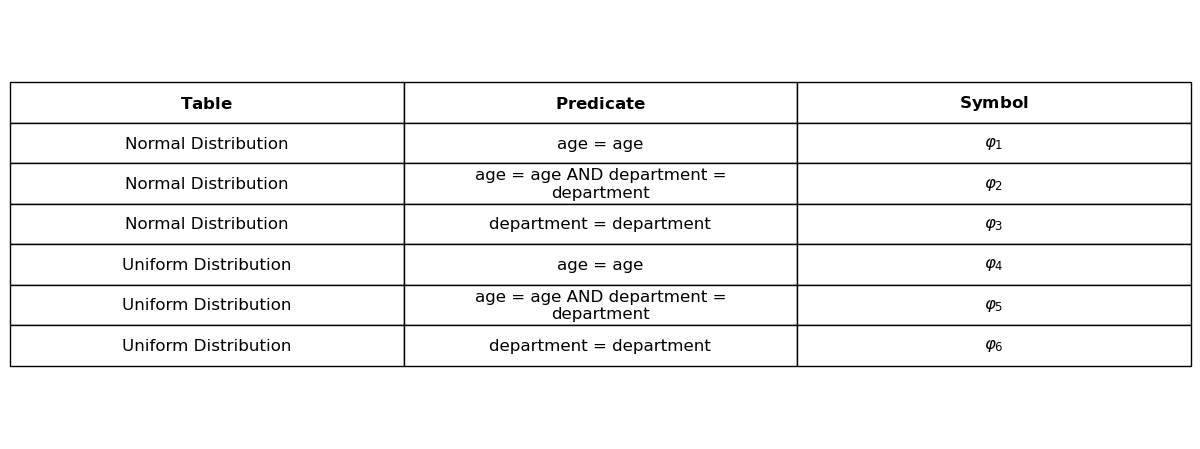

In [6]:
unique_pairs = final_results[['dataset_name', 'predicate']].drop_duplicates().reset_index(drop=True)
association_map = {}

for idx, (dataset_name, predicate) in unique_pairs.iterrows():
  symbol = f"$\\varphi_{{{idx + 1}}}$"
  association_map[(dataset_name, predicate)] = symbol

display_data = [
  (dataset_name, '\n'.join(textwrap.wrap(predicate, width=30)), symbol)
  for (dataset_name, predicate), symbol in association_map.items()
]
display_df = pd.DataFrame(display_data, columns=['Table', 'Predicate', 'Symbol'])

fig, ax = plt.subplots(figsize=(12, len(display_df) * 0.6 + 1))
ax.axis('off')

mpl_table = ax.table(cellText=display_df.values,
                     colLabels=[fr'$\mathbf{{{col}}}$' for col in display_df.columns],
                     cellLoc='center',
                     loc='center')

mpl_table.auto_set_font_size(False)
mpl_table.set_fontsize(12)
mpl_table.scale(1.2, 2.0)

for key, cell in mpl_table.get_celld().items():
  cell.set_text_props(wrap=True, verticalalignment='center')

plt.tight_layout()
plt.show()

### Plotting build time.

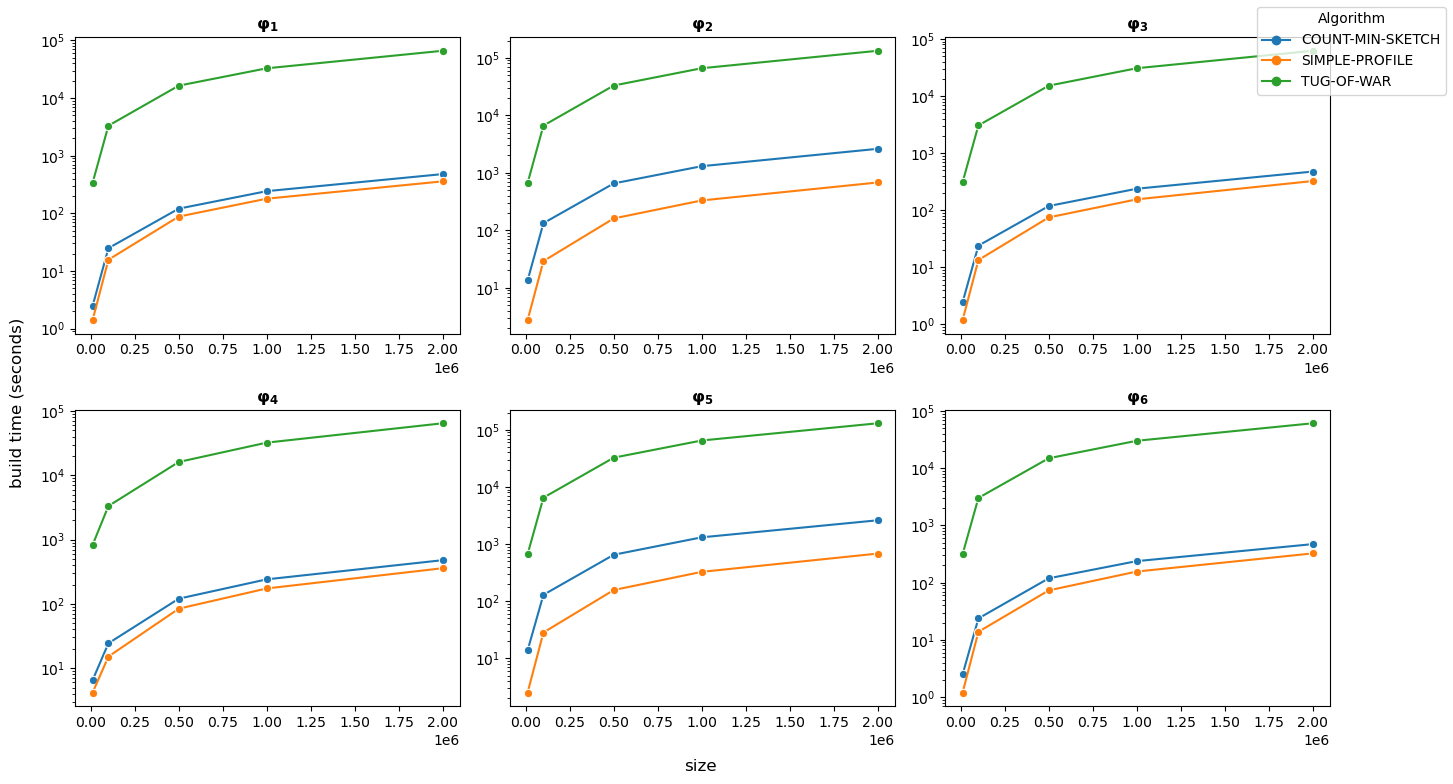

In [7]:
# NOTE: AI Generated Code.

# Get all unique algorithms to fix color order
algorithms = final_results['algorithm'].unique()

unique_pairs = final_results[['dataset_name', 'predicate']].drop_duplicates().reset_index(drop=True)
n_plots = len(unique_pairs)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols

non_zero_build_times = final_results['build_time'][final_results['build_time'] > 0]
global_min = non_zero_build_times.min()
global_max = non_zero_build_times.max()

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
axes = axes.flatten()

for i, (dataset_name, predicate) in unique_pairs.iterrows():
    ax = axes[i]
    subset = final_results[(final_results['dataset_name'] == dataset_name) & 
                           (final_results['predicate'] == predicate)]
    
    # Sort the subset by table_size before plotting
    subset = subset.sort_values(by='table_size')
    
    symbol = association_map.get((dataset_name, predicate), '')  # Get symbol

    sns.lineplot(data=subset, 
                 x='table_size', 
                 y='build_time', 
                 hue='algorithm', 
                 hue_order=algorithms,
                 marker='o', 
                 ax=ax,
                 legend=False)

    ax.set_yscale('log')
    # print(f'\\{symbol.split('$')[1].split('\\')[1]}') # debug
    ax.set_title(f"$\\mathbf{{{f'\\{symbol.split('$')[1].split('\\')[1]}'}}}$", fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')


# Remove unused subplots
for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

# Common labels
fig.text(0.5, 0.04, 'size', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'build time (seconds)', va='center', rotation='vertical', fontsize=12)

# Create a single legend for the entire figure
# Use a dummy plot to create handles and labels for the legend

palette = sns.color_palette(n_colors=len(algorithms))
handles = [Line2D([0], [0], color=palette[i], marker='o', linestyle='-') for i in range(len(algorithms))]
fig.legend(handles, algorithms, title='Algorithm', loc='upper right', fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 0.93, 1])  # leave space for legend on the right
plt.show()

### Plotting estimation time.

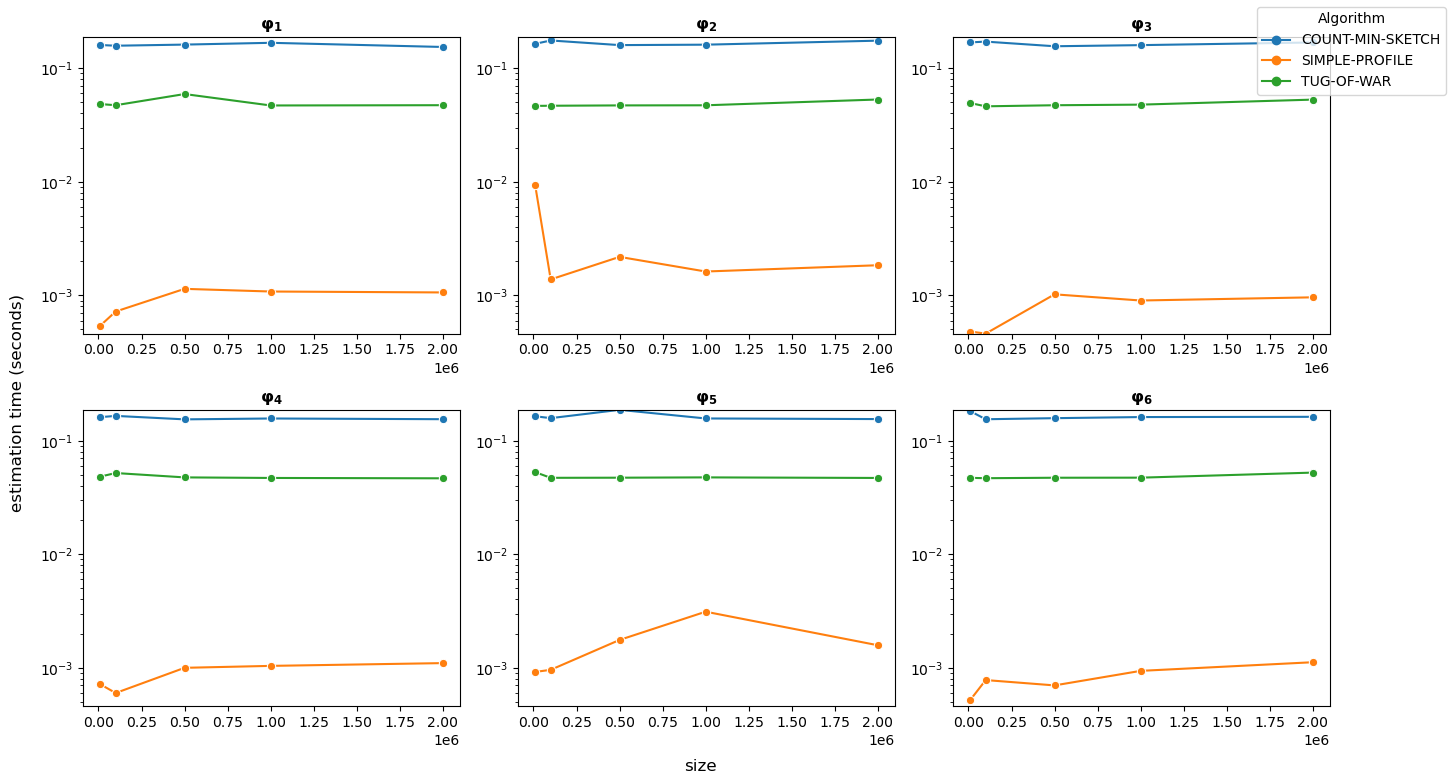

In [8]:
# NOTE: AI Generated Code.

# Get all unique algorithms for consistent hue order
algorithms = final_results['algorithm'].unique()

# Unique dataset/predicate pairs
unique_pairs = final_results[['dataset_name', 'predicate']].drop_duplicates().reset_index(drop=True)

# Generate symbols for each unique (dataset_name, predicate)
association_map = {
    (dataset_name, predicate): f"$\\varphi_{{{idx + 1}}}$"
    for idx, (dataset_name, predicate) in unique_pairs.iterrows()
}

# Subplot layout
n_plots = len(unique_pairs)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols

non_zero_est_times = final_results['estimation_time'][final_results['estimation_time'] > 0]
global_min = non_zero_est_times.min()
global_max = non_zero_est_times.max()

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
axes = axes.flatten()

# Plot each (dataset, predicate) combination
for i, (dataset_name, predicate) in unique_pairs.iterrows():
    ax = axes[i]
    subset = final_results[
        (final_results['dataset_name'] == dataset_name) &
        (final_results['predicate'] == predicate)
    ]
    
    # Sort the subset by table_size before plotting
    subset = subset.sort_values(by='table_size')
    
    symbol = association_map.get((dataset_name, predicate), '')

    sns.lineplot(
        data=subset,
        x='table_size',
        y='estimation_time',
        hue='algorithm',
        hue_order=algorithms,
        marker='o',
        ax=ax,
        legend=False
    )

    ax.set_yscale('log')
    ax.set_ylim(global_min, global_max)
    # ax.set_title(f"$\\bf{{{symbol}}}$", fontsize=10)    
    ax.set_title(f"$\\mathbf{{{f'\\{symbol.split('$')[1].split('\\')[1]}'}}}$", fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Remove any unused subplots
for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

# Common X and Y labels
fig.text(0.5, 0.04, 'size', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'estimation time (seconds)', va='center', rotation='vertical', fontsize=12)

# Create a single shared legend
palette = sns.color_palette(n_colors=len(algorithms))
handles = [
    Line2D([0], [0], color=palette[i], marker='o', linestyle='-')
    for i in range(len(algorithms))
]
fig.legend(
    handles, algorithms, title='Algorithm',
    loc='upper right', fontsize=10
)

plt.tight_layout(rect=[0.05, 0.05, 0.93, 1])  # Leave room for common legend
plt.show()